In [11]:
import json
from pathlib import Path
import os

import torch
import numpy as np
from datasets import load_dataset
from huggingface_hub import snapshot_download

In [ ]:
def find_experiment_dir(config: dict, path: str | Path) -> Path | None:
    """Return the top-level subdirectory of `path` whose experiment_config.json contains all key-value pairs in `config`."""
    for subdir in Path(path).iterdir():
        cfg_file = subdir / "experiment_config.json"
        if not subdir.is_dir() or not cfg_file.exists():
            continue
        with open(cfg_file) as f:
            saved = json.load(f)
        if all(saved.get(k) == v for k, v in config.items()):
            return subdir
    return None

In [5]:
repo_id = 'eturok-weizmann/vibrations'
ds = load_dataset(repo_id, split='train', columns=["experiment_config"], download_mode='force_redownload', verification_mode='no_checks')
# snapshot_dir = snapshot_download(repo_id, repo_type="dataset", allow_patterns="data/sample_*.npz")

To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 99 examples [00:00, 1326.43 examples/s]


In [6]:
ds

Dataset({
    features: ['experiment_config'],
    num_rows: 99
})

In [12]:
idx = -1
exp_config = json.loads(ds[idx]["experiment_config"])
exp_config

{'ROI_ROW_HEIGHT': 30,
 'N_ROI_ROWS': 10,
 'N_ROI_COLUMNS': 10,
 'ROI_COLUMN_WIDTH': 70,
 'CALIBRATION_FPS': 500,
 'CALIBRATION_EXPOSURE': 30,
 'CALIBRATION_GAIN': 3,
 'FPS': 2500,
 'EXPOSURE': 150,
 'GAIN': 1,
 'BUFFER_PART_COUNT': 3000,
 'EXPOSURE_MS': 30,
 'FRAME_RATE': 30,
 'PIXEL_CLOCK': 86,
 'CAMERA_GAIN': 60,
 'RESIZE_FACTOR': 0.75,
 'GAMMA': 1.0,
 'AUDIO_FILE': '..\\data\\audio_samples\\chirp_50_1000_3.0sec.wav',
 'N_CAPTURE_SECONDS': 3.1,
 'speakers': [0, 1, 0, 0],
 'object': 'cube',
 'n_objects': 1,
 'box_material': 'cardboard'}

In [22]:
import shutil

for idx, row in enumerate(ds):
    exp_config = json.loads(row["experiment_config"])
    sample_dir = find_experiment_dir(exp_config, r"C:\Users\eitanturok\experiments\experiment-15")
    print(f'{idx=}, {sample_dir=}')
    try:
        shutil.rmtree(sample_dir)
        print('deleted')
    except Exception as e:
        print(e)

idx=0, sample_dir=None
lstat: path should be string, bytes or os.PathLike, not NoneType
idx=1, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/empty_1000--31-03-18-14-12')
deleted
idx=2, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_0001--31-03-18-21-24')
deleted
idx=3, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_0010--31-03-18-21-22')
deleted
idx=4, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_0100--31-03-18-21-20')
deleted
idx=5, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x01y_1000--31-03-18-21-18')
deleted
idx=6, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x02y_0001--31-03-18-27-14')
deleted
idx=7, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/cube-00x02y_0010--31-03-18-27-11')
deleted
idx=8, sample_dir=WindowsPath('C:/Users/eitanturok/experiments/experiment-15/c

In [16]:
data = np.load(os.path.join(snapshot_dir, f"data/sample_{ds[idx]['sample_idx']}.npz"))
shifts, mask = torch.from_numpy(data['shifts']), torch.from_numpy(data['mask'].astype(np.float32)) 

In [20]:
shifts.shape

torch.Size([100, 9000, 2])

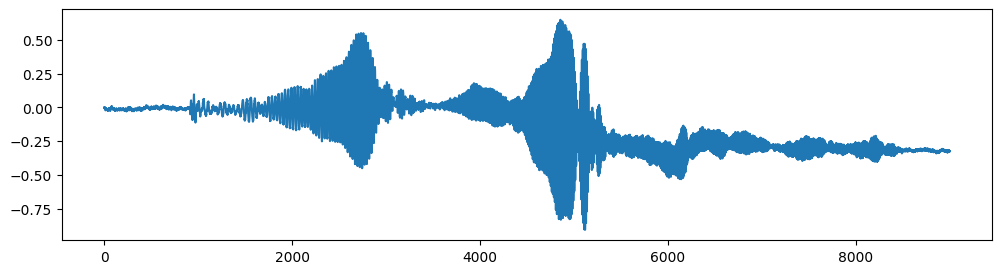

In [22]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(shifts[50, :, 1])
plt.show()